In [8]:
%load_ext autoreload
%autoreload 2

# Сравнение MLP, RNN и CNN для классификации изображений

В данной работе проводится сравнительный анализ различных архитектур нейронных сетей.
Цель исследования — определить влияние архитектуры модели на качество классификации изображений.

## Постановка задачи
Задача заключается в классификации медицинских изображений с использованием различных типов нейронных сетей.

В рамках работы рассматриваются три архитектуры:
- Полносвязная нейронная сеть (MLP)
- Рекуррентная нейронная сеть (RNN)
- Сверточная нейронная сеть (CNN)

Все модели обучаются и тестируются на одном и том же датасете, что позволяет провести корректное сравнение их эффективности.

## Датасет

В работе используется датасет Medical MNIST, содержащий медицинские изображения, разделённые на несколько классов.

Перед подачей в модель изображения проходят этап предобработки:
- изменение размера
- преобразование в тензоры
- нормализация

## Загрузка и предобработка данных

На данном этапе выполняется загрузка датасета и применение преобразований к изображениям.

In [2]:
import torch
import torch.nn as nn
import os
import json
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns

from models.mlp import MLP
from models.cnn import CNN
from models.rnn import RNN

from utils.train import train
from utils.evaluate import evaluate, count_params, plot_confusion_matrix, get_confusion_matrix
from utils.dataset import get_dataloaders, get_class_names, get_dataset_info

def save_experiment(model, name, acc, losses, time):
    os.makedirs(f"experiments/{name}", exist_ok=True)
    os.makedirs("checkpoints", exist_ok=True)

    torch.save(model.state_dict(), f"checkpoints/{name}.pth")

    results = {
        "model": name,
        "accuracy": acc,
        "train_loss": losses,
        "train_time": time
    }

    with open(f"experiments/{name}/results.json", "w") as f:
        json.dump(results, f, indent=4)

def run_experiment(model, name, train_loader, test_loader, epochs=5, lr=1e-3):
    model = model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_losses = []

    start = time.time()

    for epoch in range(epochs):
        loss = train(model, train_loader, optimizer, criterion, device)
        train_losses.append(loss)

        print(f"{name} | Epoch {epoch+1}/{epochs} | Loss: {loss:.4f}")

    end = time.time()
    train_time = end - start
    acc = evaluate(model, test_loader, device)

    save_experiment(model, name, acc, train_losses, train_time)

    return acc, train_losses

device = torch.device("mps" if torch.backends.mps.is_built() else "cpu")
torch.manual_seed(42)

data_dir = "data/Medical_MNIST"
dataset_info = get_dataset_info(data_dir)

print("Характеристики набора данных Medical MNIST:")
dataset_df = pd.DataFrame(dataset_info, index=[0]).T.rename(columns={0: "Value"})
display(dataset_df)

img_size = dataset_info["height"]
input_size = img_size * img_size
gray_scale = (dataset_info["channels"] == 1)

train_loader, test_loader = get_dataloaders(data_dir, batch_size=32, image_size=img_size, gray_scale=gray_scale)
classes = get_class_names(data_dir)

ru_map = {
    "AbdomenCT": "КТ брюшной полости",
    "BreastMRI": "МРТ молочной железы",
    "CXR": "Рентген грудной клетки",
    "ChestCT": "КТ грудной клетки",
    "Hand": "Рентген кисти",
    "HeadCT": "КТ головы"
}

classes_df = pd.DataFrame({
    "Class Name": classes,
    "Class Name (RU)": [ru_map[c] for c in classes]
}).rename(columns={0: "Class Index"})
print("Наименования классов:")
display(classes_df)

Характеристики набора данных Medical MNIST:


,Value
channels,1
height,64
width,64


Наименования классов:


,Class Name,Class Name (RU)
0,AbdomenCT,КТ брюшной полости
1,BreastMRI,МРТ молочной железы
2,CXR,Рентген грудной клетки
3,ChestCT,КТ грудной клетки
4,Hand,Рентген кисти
5,HeadCT,КТ головы


## Эксперимент 1: Полносвязная нейронная сеть (MLP)

Полносвязная нейронная сеть рассматривает изображение как одномерный вектор признаков.

Недостатком данного подхода является игнорирование пространственной структуры изображения.

In [3]:
mlp = MLP(input_size=input_size)
mlp_acc, mlp_loss = run_experiment(mlp, "MLP", train_loader, test_loader)

MLP | Epoch 1/5 | Loss: 0.0890
MLP | Epoch 2/5 | Loss: 0.0341
MLP | Epoch 3/5 | Loss: 0.0210
MLP | Epoch 4/5 | Loss: 0.0298
MLP | Epoch 5/5 | Loss: 0.0179


## Эксперимент 2: Рекуррентная нейронная сеть (RNN)

Для применения рекуррентной сети изображение преобразуется в последовательность (например, по строкам).

Данный подход позволяет использовать временные зависимости, однако не учитывает двумерную структуру изображения в полной мере.

In [4]:
rnn = RNN(input_size=img_size, hidden_size=img_size)
rnn_acc, rnn_loss = run_experiment(rnn, "RNN", train_loader, test_loader)

RNN | Epoch 1/5 | Loss: 0.1711
RNN | Epoch 2/5 | Loss: 0.0593
RNN | Epoch 3/5 | Loss: 0.0491
RNN | Epoch 4/5 | Loss: 0.0458
RNN | Epoch 5/5 | Loss: 0.0577


## Эксперимент 3: Сверточная нейронная сеть (CNN)

Сверточные нейронные сети специально разработаны для обработки изображений.

Они учитывают локальные пространственные зависимости и обладают свойством инвариантности к сдвигу.

In [5]:
cnn = CNN()
cnn_acc, cnn_loss = run_experiment(cnn, "CNN", train_loader, test_loader)

CNN | Epoch 1/5 | Loss: 0.2099
CNN | Epoch 2/5 | Loss: 0.0261
CNN | Epoch 3/5 | Loss: 0.0178
CNN | Epoch 4/5 | Loss: 0.0127
CNN | Epoch 5/5 | Loss: 0.0115


## Сравнение результатов

### Сводная таблица метрик

В данном разделе проводится количественное сравнение обученных моделей на тестовой выборке.
Для каждой архитектуры (MLP, RNN, CNN) загружаются ранее сохранённые результаты экспериментов, включающие ключевые метрики качества и эффективности.

В частности, для каждой модели анализируются:

* Accuracy — доля правильно классифицированных изображений на тестовой выборке
* Loss — значение функции потерь на последней эпохе обучения
* Time — общее время обучения модели
* Params — количество обучаемых параметров модели

Дополнительно вычисляется количество параметров каждой модели, что позволяет оценить их вычислительную сложность и сравнить эффективность архитектур не только по качеству, но и по ресурсоёмкости.

In [6]:
def load_results(path):
    with open(path, "r") as f:
        return json.load(f)
def load_model():
    pass

results_dir = "experiments"
results_list = []

for model_name in os.listdir(results_dir):
    model_path = os.path.join(results_dir, model_name)

    if os.path.isdir(model_path):
        results_file = os.path.join(model_path, "results.json")

        if os.path.exists(results_file):
            data = load_results(results_file)
            results_list.append(data)

params_dict = {
    "MLP": count_params(mlp),
    "RNN": count_params(rnn),
    "CNN":count_params(cnn)
}

results_df = pd.DataFrame([
    {
        "Model": r["model"],
        "Accuracy": r["accuracy"],
        "Loss": r["train_loss"][-1],
        "Time": r["train_time"]
    }
    for r in results_list
])
results_df["Params"] = results_df["Model"].map(params_dict)

display(results_df)

,Model,Accuracy,Loss,Time,Params
0,CNN,0.996184,0.011536,107.634123,9798
1,RNN,0.986854,0.057728,123.734991,8710
2,MLP,0.994487,0.017869,70.271063,2230534


Наивысшую точность классификации демонстрирует CNN (0.996), что подтверждает её способность эффективно извлекать пространственные признаки изображений. При этом значение функции потерь у данной модели также является минимальным, что указывает на более стабильное и уверенное обучение по сравнению с другими архитектурами.

MLP показывает близкое значение точности (0.994), однако при этом обладает значительно большим числом параметров (более 2 млн). Это указывает на высокую вычислительную сложность модели при отсутствии явных преимуществ в качестве классификации по сравнению с CNN.

RNN демонстрирует наименьшую точность среди трёх моделей (0.986), а также более высокое значение функции потерь. Это связано с тем, что архитектура рекуррентной сети не является естественной для обработки изображений, так как не учитывает двумерную пространственную структуру данных.

### Визуальное сравнение качества моделей

Для наглядного анализа эффективности моделей используются графические методы визуализации. Это позволяет не только сравнить итоговые метрики, но и проанализировать процесс обучения.

Первый график представляет собой столбчатую диаграмму, которая отображает итоговую точность (Accuracy) каждой модели на тестовой выборке.

Каждой архитектуре соответствует свой цвет:

* MLP — красный
* CNN — зелёный
* RNN — синий

Второй график отображает изменение функции потерь (Loss) в процессе обучения по эпохам для каждой модели.

Анализ данного графика позволяет:

- оценить скорость сходимости моделей
- выявить возможное переобучение
- сравнить стабильность обучения различных архитектур


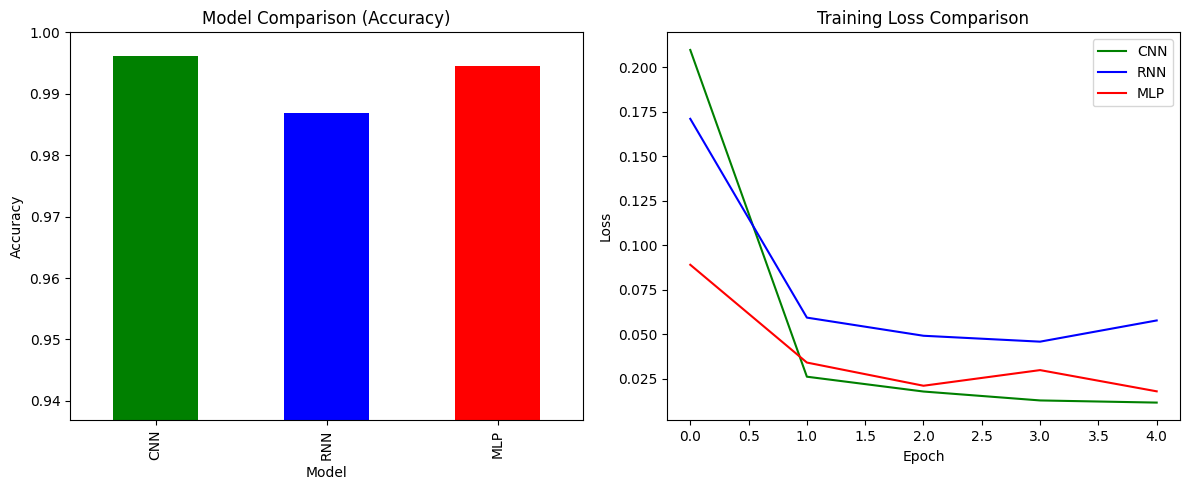

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
baseline = results_df["Accuracy"].min()

models = {
    "MLP": mlp,
    "CNN": cnn,
    "RNN": rnn
}
color_map = {
    "MLP": "Red",
    "CNN": "Green",
    "RNN": "Blue"
}

colors = results_df["Model"].map(color_map)

results_df.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    legend=False,
    ax=axes[0],
    color=colors
)

axes[0].set_title("Model Comparison (Accuracy)")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(baseline - 0.05, 1.0)

for r in results_list:
    axes[1].plot(r["train_loss"], label=r["model"], color = color_map[r["model"]])

axes[1].set_title("Training Loss Comparison")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

### Анализ ошибок классификации

Для проведения сравнительного анализа характера ошибок каждой модели при одинаковых условиях обучения и тестирования воспользуемся матрицей ошибок (confusion matrix). Данный инструмент позволяет детально исследовать, какие классы изображений модель классифицирует корректно, а какие - путает между собой.

Для каждой архитектуры (MLP, CNN, RNN) выполняется получение предсказаний на тестовой выборке, строится отдельная матрица ошибок и визуализируется в виде тепловой карты, где строки соответствую истинным классам, а столбцы - предсказанным.

Диагональные элементы отражают количество верных классификаций, тогда как внедиагональные элементы показывают ошибки модели.

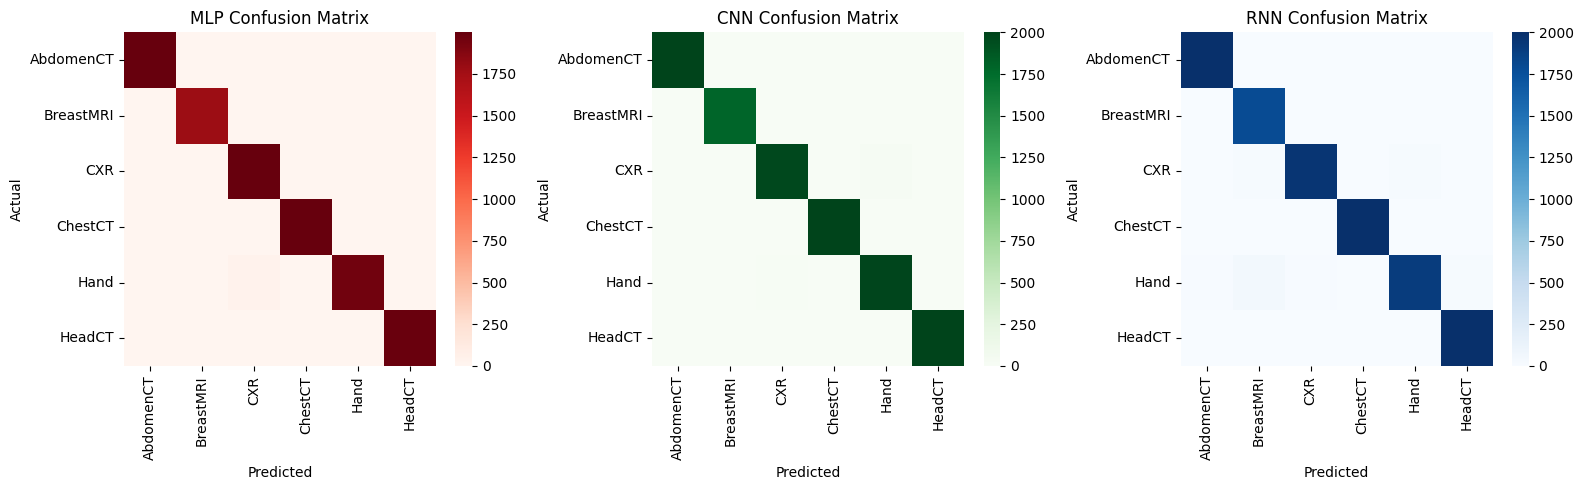

In [13]:
per_class_dict = {}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, model) in zip(axes, models.items()):
    cm = get_confusion_matrix(model=model,
                              test_loader=test_loader,
                              device=device,)
    plot_confusion_matrix(
        cm=cm,
        classes=classes,
        ax=ax,
        color=color_map[name] + "s",
        title=f"{name} Confusion Matrix"
    )
    per_class_acc = cm.diagonal()/cm.sum(axis=1)
    per_class_dict[name] = per_class_acc

plt.tight_layout()
plt.show()

### Оценка точности классификации по отдельным классам

Для более детального анализа качества моделей используется метрика per-class accuracy, которая позволяет оценить точность классификации отдельно для каждого класса изображений. Per-class accuracy показывает, какая доля объектов конкретного класса была правильно классифицирована моделью. В отличие от общей точности, данная метрика позволяет выявить слабые и сильные стороны модели на уровне отдельных категорий данных.

Метрика вычисляется на основе матрицы ошибок (confusion matrix) следующим образом:

$$Accuracy_i = \frac{CM_{ii}}{\sum_j CM_{ij}}$$

где:

* $CM_{ii}$ — количество правильно классифицированных объектов $i$-го класса
* $\sum_j CM_{ij}$ — общее количество объектов $i$-го класса

In [15]:
per_class_df = pd.DataFrame(per_class_dict, index=classes)
display(per_class_df)

,MLP,CNN,RNN
AbdomenCT,0.999500,1.0000,1.0000
BreastMRI,0.998325,1.0000,1.0000
CXR,0.998000,0.9845,0.9790
ChestCT,0.999500,1.0000,0.9970
Hand,0.977500,0.9930,0.9500
HeadCT,0.994500,1.0000,0.9965


Из полученной таблицы видно, что все модели демонстрируют высокое качество классификации на большинстве классов. Однако наблюдаются различия в устойчивости моделей к отдельным категориям данных:

* CNN показывает наиболее стабильные и высокие значения per-class accuracy практически для всех классов, что подтверждает её эффективность для задач обработки изображений.
* MLP также демонстрирует высокие значения точности, однако в некоторых классах наблюдается небольшое снижение качества, связанное с отсутствием учета пространственной структуры изображений.
* RNN показывает сопоставимые результаты, но уступает CNN на части классов, что объясняется неестественностью представления изображений как последовательности.

## Вывод

В ходе работы было проведено сравнение различных архитектур нейронных сетей для задачи классификации изображений.

Полученные результаты показывают:

- Полносвязные сети демонстрируют наихудшие результаты, так как не учитывают структуру изображения.
- Рекуррентные сети показывают среднее качество, поскольку изображение не является естественной последовательностью.
- Сверточные нейронные сети достигают наилучших результатов благодаря учёту пространственных зависимостей.

Таким образом, выбор архитектуры нейронной сети должен соответствовать структуре входных данных.